# segments_reduced 是什么

`integrate_fermi_surface_observables(model, segments_reduced, recip_lat_vecs)` 里的 `segments_reduced` 是费米面折线列表。

更具体地说：

- `segments_reduced` 是一个 `list[np.ndarray]`。
- 列表里的每个 `segment` 是一个形状为 `(N, 2)` 的数组。
- 每一行是一个 reduced reciprocal coordinate：`[k1, k2]`。
- 这些点连起来就是一条满足 `E_lower(k1, k2) = mu` 的等能线，也就是二维体系里的费米线。

所以 `segment` 不是能量，也不是速度；它只是费米线在 reduced k 坐标里的采样点。后面的积分会把它转成 Cartesian k 坐标，计算每一小段长度 `ds`。

In [22]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo = Path.cwd()
if repo.name == "learning_code":
    repo = repo.parents[1]
elif not (repo / "quantum_geometry").exists():
    repo = Path("/home/mayuan/code/sctheory")

tb_dir = repo / "quantum_geometry" / "graphene" / "tb"
sys.path.insert(0, str(tb_dir))

from core import (  # noqa: E402
    GrapheneParameters,
    build_model,
    uniform_mesh_quantities,
    extract_fermi_surface_segments,
    extract_dirac_pocket_segments,
    reduced_k_to_cartesian,
    evaluate_band_quantities_on_points,
)

## 0. 可视化辅助函数

下面这些函数只是为了把数组画清楚：能量背景、费米线点、segment 起点、中点、弧长、采样物理量和积分核都会在后面的图里出现。

In [23]:
from matplotlib.collections import LineCollection


def lower_band_grid(mesh):
    size = int(mesh["mesh_size"])
    return mesh["evals_ev"][:, 0].reshape(size, size)


def plot_energy_map_with_segments(ax, mesh, segments, mu, title, xlim=(0, 1), ylim=(0, 1)):
    size = int(mesh["mesh_size"])
    u = np.arange(size) / size
    v = np.arange(size) / size
    uu, vv = np.meshgrid(u, v, indexing="ij")
    energy = lower_band_grid(mesh)

    im = ax.contourf(uu, vv, energy, levels=60, cmap="magma", alpha=0.82)
    ax.contour(uu, vv, energy, levels=[mu], colors="white", linewidths=1.1)

    for i, seg in enumerate(segments):
        ax.plot(seg[:, 0], seg[:, 1], lw=2.0, label=f"segment {i}: {seg.shape}")
        ax.scatter(seg[:, 0], seg[:, 1], s=10)
        ax.scatter(seg[0, 0], seg[0, 1], s=55, marker="o", edgecolor="black", label=f"start {i}")
        step = max(1, len(seg) // 8)
        for point_idx in range(0, len(seg), step):
            ax.text(seg[point_idx, 0], seg[point_idx, 1], str(point_idx), fontsize=7, color="white")

    ax.scatter([2/3, 1/3], [1/3, 2/3], marker="x", s=85, c="cyan", label="K / K'")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("reduced k1")
    ax.set_ylabel("reduced k2")
    ax.set_title(title)
    ax.legend(fontsize=7, loc="upper right")
    return im


def segment_data_for_integral(segment, model, recip_lat_vecs):
    seg_cart = reduced_k_to_cartesian(segment, recip_lat_vecs)
    mid_reduced = 0.5 * (segment[:-1] + segment[1:])
    ds = np.linalg.norm(seg_cart[1:] - seg_cart[:-1], axis=1)
    s_mid = np.cumsum(ds) - 0.5 * ds
    sampled = evaluate_band_quantities_on_points(model, mid_reduced, recip_lat_vecs)
    safe_velocity = np.maximum(sampled["velocity_norm"], 1.0e-12)
    safe_gap_sq = np.maximum(sampled["gap_ev"] ** 2, 1.0e-12)
    kernels = {
        "dos: ds/|v|": ds / safe_velocity,
        "lambda_E: ds|v|": ds * safe_velocity,
        "lambda_geo: ds gap^2 Tr(g)/|v|": ds * safe_gap_sq * sampled["metric_trace"] / safe_velocity,
        "topo denom: ds|v|/gap^2": ds * safe_velocity / safe_gap_sq,
    }
    return {
        "segment_reduced": segment,
        "segment_cart": seg_cart,
        "mid_reduced": mid_reduced,
        "ds": ds,
        "s_mid": s_mid,
        "sampled": sampled,
        "kernels": kernels,
    }


def plot_segment_integral_data(data, title):
    seg = data["segment_reduced"]
    seg_cart = data["segment_cart"]
    mid = data["mid_reduced"]
    ds = data["ds"]
    s_mid = data["s_mid"]
    sampled = data["sampled"]
    kernels = data["kernels"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

    ax = axes[0, 0]
    point_color = np.arange(len(seg))
    sc = ax.scatter(seg[:, 0], seg[:, 1], c=point_color, cmap="viridis", s=25)
    ax.plot(seg[:, 0], seg[:, 1], color="0.25", lw=1.0)
    ax.scatter(mid[:, 0], mid[:, 1], s=8, c="red", label="midpoints")
    ax.scatter(seg[0, 0], seg[0, 1], s=80, marker="o", edgecolor="black", label="start")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("reduced k1")
    ax.set_ylabel("reduced k2")
    ax.set_title("segment points and midpoints")
    ax.legend(fontsize=8)
    fig.colorbar(sc, ax=ax, label="point index")

    ax = axes[0, 1]
    lines = np.stack([seg_cart[:-1], seg_cart[1:]], axis=1)
    lc = LineCollection(lines, array=ds, cmap="plasma", linewidths=2.5)
    ax.add_collection(lc)
    ax.scatter(seg_cart[:, 0], seg_cart[:, 1], s=10, c="0.1")
    ax.autoscale()
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("cartesian kx")
    ax.set_ylabel("cartesian ky")
    ax.set_title("cartesian segment, colored by ds")
    fig.colorbar(lc, ax=ax, label="ds")

    ax = axes[1, 0]
    ax.plot(s_mid, sampled["velocity_norm"], label="|grad E|")
    ax.plot(s_mid, sampled["gap_ev"], label="gap")
    ax.plot(s_mid, sampled["metric_trace"], label="Tr(g)")
    ax.set_xlabel("arc length midpoint")
    ax.set_title("sampled quantities on segment midpoints")
    ax.legend(fontsize=8)

    ax = axes[1, 1]
    for name, values in kernels.items():
        ax.plot(s_mid, values, label=f"{name}, sum={values.sum():.3g}")
    ax.set_xlabel("arc length midpoint")
    ax.set_title("integral kernels accumulated along this segment")
    ax.legend(fontsize=7)

    fig.suptitle(title)
    plt.show()

## 1. 建立石墨烯模型并计算均匀 k 网格

`uniform_mesh_quantities()` 会在 reduced k 坐标的 `[0, 1) x [0, 1)` 区域生成均匀网格，并计算下带能量、能隙、量子度规等。这里我们只用下带能量来抽取费米线。

In [24]:
params = GrapheneParameters()
model = build_model(params)

mesh_size = 180
mesh = uniform_mesh_quantities(model, mesh_size=mesh_size)

lower_band = mesh["evals_ev"][:, 0] # 从 mesh 里面取出所有 k 点的能带本征值，然后只取第 0 条能带，也就是最低能带。
recip_lat_vecs = mesh["recip_lat_vecs"]

print("k_pts shape:", mesh["k_pts"].shape)
print("lower_band shape:", lower_band.shape)
print("energy range:", lower_band.min(), lower_band.max())

k_pts shape: (32400, 2)
lower_band shape: (32400,)
energy range: -8.253000000605839 -0.0001


## 2. 用 contour 抽取一条普通费米线

`extract_fermi_surface_segments(lower_band, mu, mesh_size)` 的本质是对二维函数 `E_lower(k1,k2)` 画等高线。

这里 `mu = -0.30 eV`，费米线比较大，适合用全局网格 contour 抽取。

In [30]:
mu_global = -3
segments_global = extract_fermi_surface_segments(lower_band, mu_global, mesh_size)

print("number of global segments:", len(segments_global))
for i, seg in enumerate(segments_global):
    print(f"segment {i}: shape = {seg.shape}")
    print(seg[:5])

number of global segments: 4
segment 0: shape = (162, 2)
[[0.         0.54911417]
 [0.00167872 0.55      ]
 [0.00555556 0.55195252]
 [0.01111111 0.55501483]
 [0.01202771 0.55555556]]
segment 1: shape = (188, 2)
[[0.45088583 0.        ]
 [0.45360304 0.00555556]
 [0.45555556 0.00994923]
 [0.45609628 0.01111111]
 [0.45850034 0.01666667]]
segment 2: shape = (186, 2)
[[0.54639696 0.99444444]
 [0.54444444 0.99005077]
 [0.54390372 0.98888889]
 [0.54149966 0.98333333]
 [0.53933881 0.97777778]]
segment 3: shape = (162, 2)
[[0.99444444 0.44804748]
 [0.98888889 0.44498517]
 [0.98797229 0.44444444]
 [0.98333333 0.44183367]
 [0.97854249 0.43888889]]


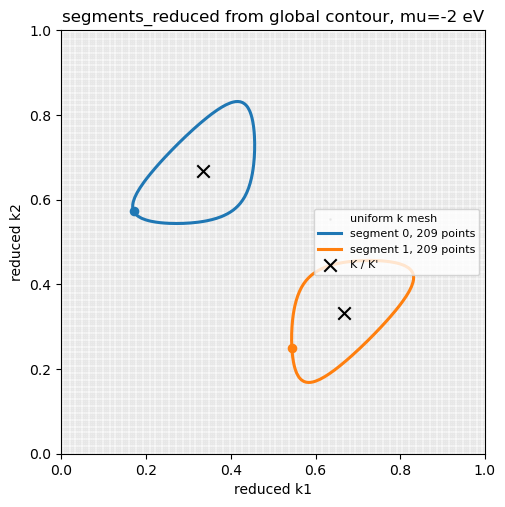

In [26]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(mesh["k_pts"][:, 0], mesh["k_pts"][:, 1], s=1, c="0.88", alpha=0.5, label="uniform k mesh")

for i, seg in enumerate(segments_global):
    ax.plot(seg[:, 0], seg[:, 1], lw=2.2, label=f"segment {i}, {seg.shape[0]} points")
    ax.scatter(seg[0, 0], seg[0, 1], s=35, marker="o")

ax.scatter([2/3, 1/3], [1/3, 2/3], marker="x", s=80, c="black", label="K / K'")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("reduced k1")
ax.set_ylabel("reduced k2")
ax.set_title(f"segments_reduced from global contour, mu={mu_global} eV")
ax.legend(fontsize=8)
plt.show()

## 3. 在 Dirac 点附近构造局部 pocket

当 `mu` 很接近 Dirac 点时，费米线是 K 和 K' 附近两个很小的 pocket。粗网格 contour 容易抽坏，所以代码里用 `extract_dirac_pocket_segments()` 沿角度方向逐点求根。

这个函数返回的仍然是同一种东西：`list[np.ndarray]`，每个数组依然是一条 reduced k 坐标下的费米线折线。

In [32]:
mu_dirac = -0.02
segments_dirac = extract_dirac_pocket_segments(model, recip_lat_vecs, mu_dirac, num_angles=360)

print("number of Dirac pocket segments:", len(segments_dirac))
for i, seg in enumerate(segments_dirac):
    print(f"segment {i}: shape = {seg.shape}")
    print(seg[:5])

number of Dirac pocket segments: 2
segment 0: shape = (361, 2)
[[0.66800435 0.33400217]
 [0.66800414 0.33402229]
 [0.66800352 0.33404219]
 [0.66800249 0.33406187]
 [0.66800105 0.33408133]]
segment 1: shape = (361, 2)
[[0.33466777 0.66733389]
 [0.33466757 0.66735396]
 [0.33466697 0.66737382]
 [0.33466597 0.66739347]
 [0.33466456 0.6674129 ]]


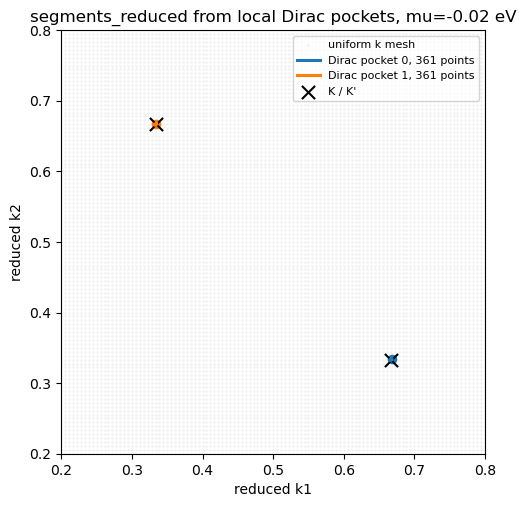

In [28]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(mesh["k_pts"][:, 0], mesh["k_pts"][:, 1], s=1, c="0.9", alpha=0.4, label="uniform k mesh")

for i, seg in enumerate(segments_dirac):
    ax.plot(seg[:, 0], seg[:, 1], lw=2.2, label=f"Dirac pocket {i}, {seg.shape[0]} points")
    ax.scatter(seg[0, 0], seg[0, 1], s=35, marker="o")

ax.scatter([2/3, 1/3], [1/3, 2/3], marker="x", s=90, c="black", label="K / K'")
ax.set_xlim(0.20, 0.80)
ax.set_ylim(0.20, 0.80)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("reduced k1")
ax.set_ylabel("reduced k2")
ax.set_title(f"segments_reduced from local Dirac pockets, mu={mu_dirac} eV")
ax.legend(fontsize=8)
plt.show()

## 4. 为什么积分函数需要这些 segment

`integrate_fermi_surface_observables()` 会对每个 `segment` 做下面几步：

1. 把 reduced 坐标转成 Cartesian reciprocal 坐标。
2. 用相邻点差分得到每一小段长度 `ds`。
3. 在每一小段中点重新计算能量、gap、metric trace 和速度。
4. 累加费米线积分：

$$
\oint \frac{ds}{|v|},\qquad
\oint ds\,|v|,\qquad
\oint ds\,\frac{\Delta E^2\,\mathrm{Tr}\,g}{|v|},\qquad
\oint ds\,\frac{|v|}{\Delta E^2}.
$$

所以 `segments_reduced` 的作用只是告诉积分函数：费米线在哪里。真正的物理量是在这些费米线点上重新采样得到的。

In [29]:
seg = segments_dirac[0]
seg_cart = reduced_k_to_cartesian(seg, recip_lat_vecs)
ds = np.linalg.norm(seg_cart[1:] - seg_cart[:-1], axis=1)
mid_reduced = 0.5 * (seg[:-1] + seg[1:])

print("one segment in reduced coords:", seg.shape)
print("same segment in cartesian reciprocal coords:", seg_cart.shape)
print("ds shape:", ds.shape)
print("first 5 ds:", ds[:5])
print("midpoints shape:", mid_reduced.shape)

one segment in reduced coords: (361, 2)
same segment in cartesian reciprocal coords: (361, 2)
ds shape: (360,)
first 5 ds: [0.00014669 0.00014669 0.00014669 0.00014669 0.00014669]
midpoints shape: (360, 2)
